# Modele 2: Arbre de decision

Pourquoi l'Arbre de Décision est une excellente suite car
Contrairement à la Régression Logistique, l'Arbre de Décision va poser des questions binaires successives.
Exemple : "Est-ce que la Saturation est < 90 % ?"
Si OUI -> KTAS 1 ou 2.
Si NON -> "Est-ce que le pouls est > 100 ?"
Cela correspond beaucoup mieux à la manière dont un infirmier de tri travaille réellement.

# 1- Chargement des bibliothèques

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import joblib

In [15]:
# On charge l'objet qui contient toute la logique de transformation
preprocessor = joblib.load('../models/preprocessor_ktas.joblib')

# 2- Chargement des données prétraitées

In [10]:
# Chargement des données prétraitées
data = np.load('../data/processed/processed_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
print(f"Données chargées : X_train {X_train.shape}, y_train {y_train.shape}")

Données chargées : X_train (1013, 20), y_train (1013,)


Forme de X_test_scaled : (254, 20)

# 3- Initialisation et entraînement du modèle

In [16]:
# Initialisation de l'arbre
dt_model = DecisionTreeClassifier(
    max_depth=5,           # On limite la profondeur pour que l'arbre reste lisible
    class_weight='balanced', # Toujours pour gérer le faible nombre de KTAS 1
    random_state=42
)

# Entraînement
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

# 4- Visualisation de l'Arbre 

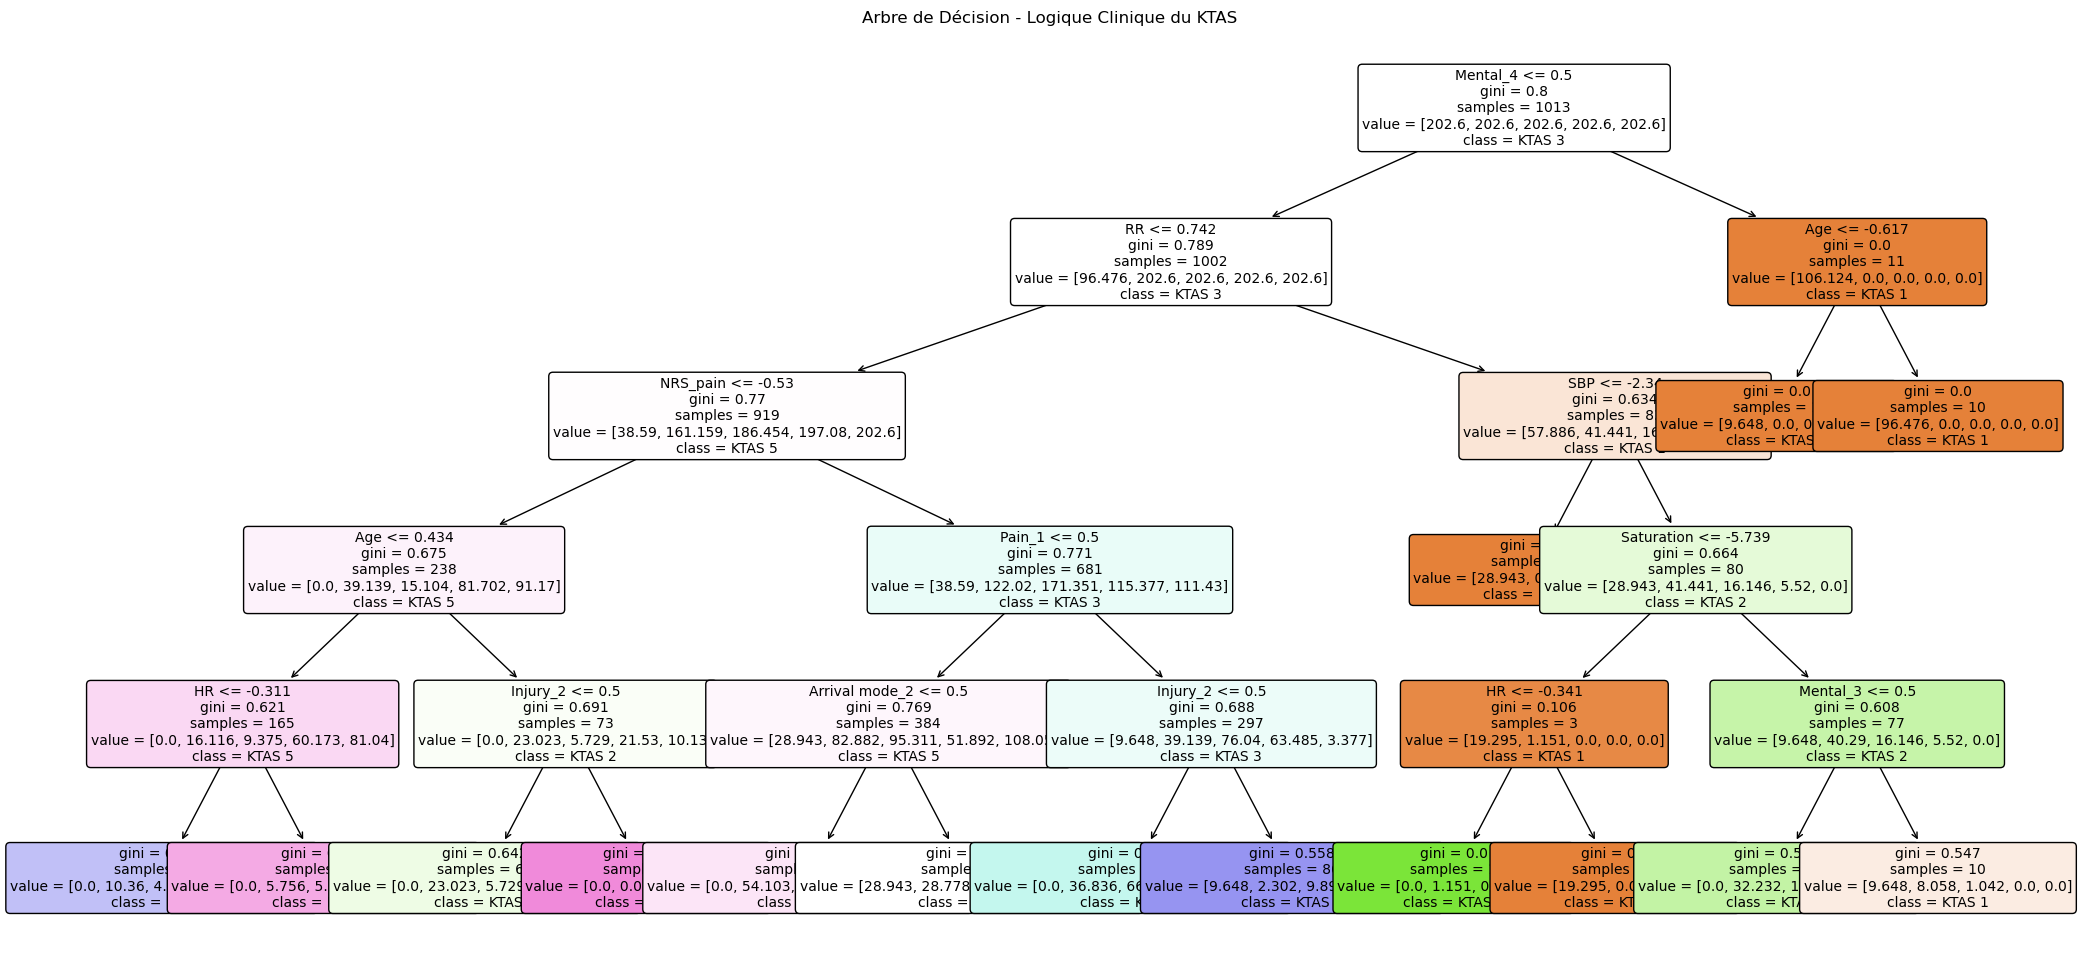

In [17]:
# 1. Liste manuelle des colonnes numériques (dans l'ordre du notebook 01)
cols_numeriques = ['Age', 'NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation']

# 2. Extraction automatique des noms générés par le OneHotEncoder
# On va chercher le transformateur nommé 'cat' dans le preprocessor
cols_cat_transformed = list(preprocessor.named_transformers_['cat'].get_feature_names_out())

# 3. Fusion des deux listes
noms_colonnes = cols_numeriques + cols_cat_transformed

plt.figure(figsize=(25,12)) # Augmentez la taille pour mieux voir les noms
plot_tree(
    dt_model, 
    feature_names=noms_colonnes,  # <--- On utilise la liste créée ci-dessus
    class_names=['KTAS 1', 'KTAS 2', 'KTAS 3', 'KTAS 4', 'KTAS 5'],
    filled=True, 
    rounded=True,
    fontsize=10
)
plt.title("Arbre de Décision - Logique Clinique du KTAS")
plt.show()

In [18]:
y_pred = dt_model.predict(X_test)

# Matrice de confusion textuelle
labels = ['KTAS 1', 'KTAS 2', 'KTAS 3', 'KTAS 4', 'KTAS 5']
conf_matrix_df = pd.DataFrame(
    confusion_matrix(y_test, y_pred), 
    index=[f'Réel {l}' for l in labels], 
    columns=[f'Prédit {l}' for l in labels]
)
display(conf_matrix_df)

,Prédit KTAS 1,Prédit KTAS 2,Prédit KTAS 3,Prédit KTAS 4,Prédit KTAS 5
Réel KTAS 1,3,0,0,0,2
Réel KTAS 2,6,7,6,5,20
Réel KTAS 3,18,18,29,4,29
Réel KTAS 4,4,12,6,36,34
Réel KTAS 5,0,1,0,1,13
